In [12]:
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import copy
import random
import sys
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
class GRU(nn.Module):

    def __init__(self,
                 hidden_size,
                 in_size = 1,
                 out_size = 1):
        super(GRU, self).__init__()
        self.gru = nn.GRU(
            input_size = in_size,
            hidden_size = hidden_size,
            batch_first = True)
        self.fc = nn.Linear(hidden_size, out_size)

    def forward(self, x, h = None):
        out, _ = self.gru(x, h)
        last_hidden_states = out[:, -1]
        out = self.fc(last_hidden_states)
        return out, last_hidden_states

In [15]:
def sliding_window(ts, features):
    X = []
    Y = []

    for i in range(features + 1, len(ts) + 1):
        X.append(ts[i - (features + 1):i - 1])
        Y.append([ts[i - 1]])

    return X, Y

def get_pjme_timeseries():
    dir_path = ".."
    df = pd.read_csv(f'{dir_path}/data/PJME_hourly.csv')
    ts = df['PJME_MW'].astype(int).values.reshape(-1, 1)[-3000:]
    return ts

def get_training_datasets(ts, features, test_len):
    X, Y = sliding_window(ts, features)

    X_train, Y_train, X_test, Y_test = X[0:-test_len],\
                                       Y[0:-test_len],\
                                       X[-test_len:],\
                                       Y[-test_len:]

    train_len = round(len(ts) * 0.7)

    X_train, X_val, Y_train, Y_val = X_train[0:train_len],\
                                     X_train[train_len:],\
                                     Y_train[0:train_len],\
                                     Y_train[train_len:]

    x_train = torch.tensor(data = X_train).float()
    y_train = torch.tensor(data = Y_train).float()

    x_val = torch.tensor(data = X_val).float()
    y_val = torch.tensor(data = Y_val).float()

    x_test = torch.tensor(data = X_test).float()
    y_test = torch.tensor(data = Y_test).float()

    return x_train, x_val, x_test,\
           y_train.squeeze(1), y_val.squeeze(1), y_test.squeeze(1)

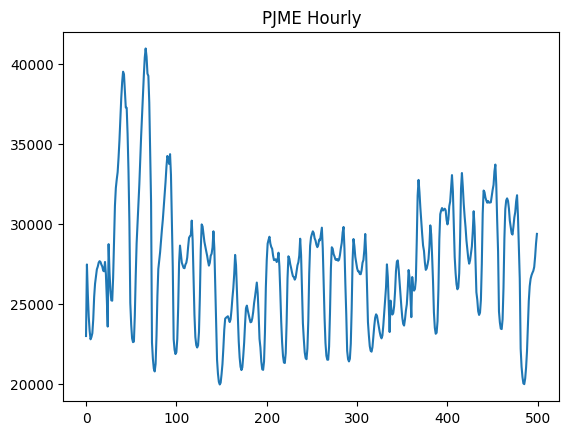

In [10]:
plt.title('PJME Hourly')
plt.plot(get_pjme_timeseries()[:500])
plt.show()

# Set random seed for reproducibility

In [13]:
random.seed(1)
torch.manual_seed(1)

# Define the parameters

In [14]:
features = 240 # length of sliding window
test_ts_len = 300 # length of test dataset
gru_hidden_size = 24 # size of GRU hidden state

learning_rate = 0.02 # Optimizer learning rate
training_epochs = 500

# Get datasets for training, validation and test

In [16]:
ts = get_pjme_timeseries()
scaler = MinMaxScaler()
scaled_ts = scaler.fit_transform(ts)
x_train, x_val, x_test, y_train, y_val, y_test =\
    get_training_datasets(scaled_ts, features, test_ts_len)

/tmp/ipykernel_9492/2336492943.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  x_train = torch.tensor(data = X_train).float()


# Initialize the model

In [17]:
model = GRU(hidden_size = gru_hidden_size)
model.train()

GRU(
  (gru): GRU(1, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)

# Define optimizer and loss function

In [18]:

optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)
mse_loss = torch.nn.MSELoss()

# Training loop

In [19]:
best_model = None
min_val_loss = sys.maxsize

training_loss = []
validation_loss = []

for t in range(training_epochs):

    prediction, _ = model(x_train)
    loss = mse_loss(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    val_prediction, _ = model(x_val)
    val_loss = mse_loss(val_prediction, y_val)

    training_loss.append(loss.item())
    validation_loss.append(val_loss.item())

    if val_loss.item() < min_val_loss:
        best_model = copy.deepcopy(model)
        min_val_loss = val_loss.item()

    if t % 50 == 0:
        print(f'epoch {t}: train - {round(loss.item(), 4)}, '
              f'val: - {round(val_loss.item(), 4)}')

epoch 0: train - 0.0448, val: - 0.0221
epoch 50: train - 0.0014, val: - 0.0024
epoch 100: train - 0.001, val: - 0.0023
epoch 150: train - 0.001, val: - 0.0023
epoch 200: train - 0.0009, val: - 0.0022
epoch 250: train - 0.0009, val: - 0.0021
epoch 300: train - 0.0008, val: - 0.002
epoch 350: train - 0.0008, val: - 0.0019
epoch 400: train - 0.0008, val: - 0.0018
epoch 450: train - 0.0009, val: - 0.002


# Evaluation at test set

In [20]:
best_model.eval()
_, h_list = best_model(x_val)
# warm hidden state
h = (h_list[-1, :]).unsqueeze(-2)

predicted = []
for test_seq in x_test.tolist():
    x = torch.Tensor(data = [test_seq])
    # passing hidden state through each iteration
    y, h = best_model(x, h.unsqueeze(-2))
    unscaled = scaler.inverse_transform(np.array(y.item()).reshape(-1, 1))[0][0]
    predicted.append(unscaled)

real = scaler.inverse_transform(y_test.tolist())

# Plot forecast results

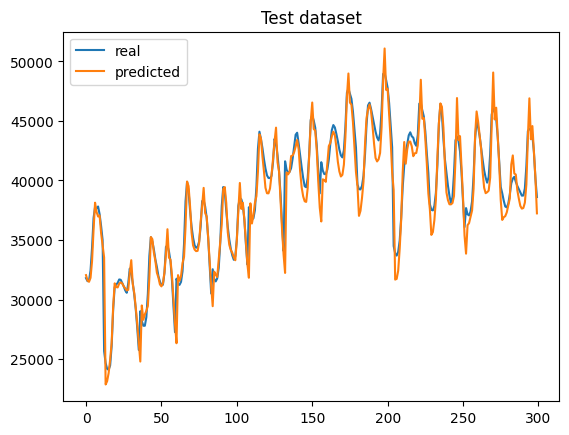

In [21]:
plt.title("Test dataset")
plt.plot(real, label = 'real')
plt.plot(predicted, label = 'predicted')
plt.legend()
plt.show()

# Plot training loss vs epochs

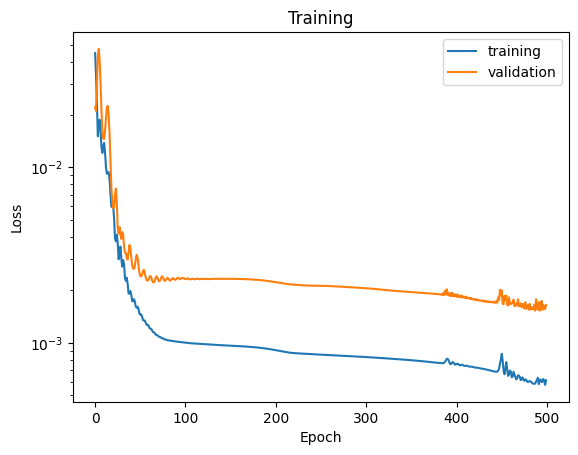

In [22]:
plt.title('Training')
plt.yscale('log')
plt.plot(training_loss, label = 'training')
plt.plot(validation_loss, label = 'validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()